Heart disease prediction using Random Forests

This code is accompanied with several tips including classes, functions and methods to use. Please note that you do not have to follow these tips, but they might be handy in some cases.

Author: Polyxeni Gkontra (polyxeni.gkontra@ub.edu)

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import pyplot as plt
import random

Read the .csv file with the patient information (TIP: you can use method [read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) from pandas)

In [33]:
file = pd.read_csv("hd_data.csv")
print(file)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

Explore your data. E.g. Print the data or few lines to see how it looks like (TIP: If you want to see just few lines consider method [head()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html#pandas.DataFrame.head) from pandas. Attribute [dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html) and function [describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html#pandas.DataFrame.describe) from the same library are useful to check the type of the data in each column and statistical properties, respectively)

In [34]:
file.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Check statistical details on your data like counts, min, max etc

Check the type of the features

In [35]:
file.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Check how many patients you have from each category

In [36]:
[file[file['HeartDisease'] > 0].count(),file[file['HeartDisease'] == 0].count()]

[Age               508
 Sex               508
 ChestPainType     508
 RestingBP         508
 Cholesterol       508
 FastingBS         508
 RestingECG        508
 MaxHR             508
 ExerciseAngina    508
 Oldpeak           508
 ST_Slope          508
 HeartDisease      508
 dtype: int64,
 Age               410
 Sex               410
 ChestPainType     410
 RestingBP         410
 Cholesterol       410
 FastingBS         410
 RestingECG        410
 MaxHR             410
 ExerciseAngina    410
 Oldpeak           410
 ST_Slope          410
 HeartDisease      410
 dtype: int64]

In [37]:
file.count()

Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64

Split your dataset into training and testing (TIP: You can use [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) method from scikit-learn. Please note that good ML practices suggest to always shuffle your data. To this end, for dataframes you can use [sample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) with the parameter frac as 1, but watch out to add reset_index(drop=True) to reset the index)

In [38]:
# Shuffle the dataset
shuffled_data = file.sample(frac=1).reset_index(drop=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    file.drop('HeartDisease', axis=1),
    file['HeartDisease'],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

Balance the training set (TIP: You can drop patients from the majority class). You can skip this step and use "class_weight" parameter of your classifier to deal with data imbalance

In [39]:
# Assuming 'HeartDisease' is the target variable and 1 is the majority class
majority_class = 1

# Identify the indices of the majority class in the training set
majority_indices = y_train[y_train == majority_class].index

# Determine the number of instances in the minority class
minority_class_count = sum(y_train != majority_class)

# Randomly select majority class indices to balance the dataset
balanced_majority_indices = majority_indices.to_list()
balanced_majority_indices = random.sample(balanced_majority_indices, k=minority_class_count)

# Combine the indices of the minority class with the balanced majority class
balanced_indices = balanced_majority_indices + y_train[y_train != majority_class].index.to_list()

# Create the balanced training set
X_train_balanced = X_train.loc[balanced_indices]
y_train_balanced = y_train.loc[balanced_indices]

Data pre-processing

1.   Encode categorical variables  (TIP: Check [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn-preprocessing-ordinalencoder) from sklearn.preprocessing. Another popular approaches is OneHotEncoder but not appropriate for tree based classifiers, can you imagine why?)
2.   Scale numerical data (TIP: Check [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler))

TIP: 1. It is very important to treat testing and training data separately to avoid data leakage 2. Methods [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit) (for training data) and [tranfrom](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit) (for the testing data) can be very helpful. Alternatively you can use Pipeline and ColumnTransformer from sklearn but it will be more complicated to retrieve feature names for the most important features

In [40]:
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
encoder = OrdinalEncoder()
X_train_balanced[categorical_columns] = encoder.fit_transform(X_train_balanced[categorical_columns])
X_test[categorical_columns] = encoder.transform(X_test[categorical_columns])


numerical_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
scaler = MinMaxScaler()
X_train_balanced[numerical_columns] = scaler.fit_transform(X_train_balanced[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


Train the model (TIP: Check method [fit](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit))

In [41]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

Apply the model to the testing data and evaluate its perfromance (TIP: You might use [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn-metrics-classification-report) or [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score))

In [44]:
# Make the prediction, using the model
y_pred = model.predict(X_test)

# Generate classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

# Evaluate the performance by comparing the predicted labels with the true ones
# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)

# Calculate accuracy, for completeness
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Generate confusion matrix, for completeness
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        77
           1       0.92      0.85      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC AUC Score: 0.8732855929117611
Accuracy: 0.8695652173913043
Confusion Matrix:
 [[69  8]
 [16 91]]


Get the feature importance in the model's estimation and plot the most important features (TIP: To get feature importance and names you can use feature_importances_ and feature_names_in_ attributes of your model, respectively)

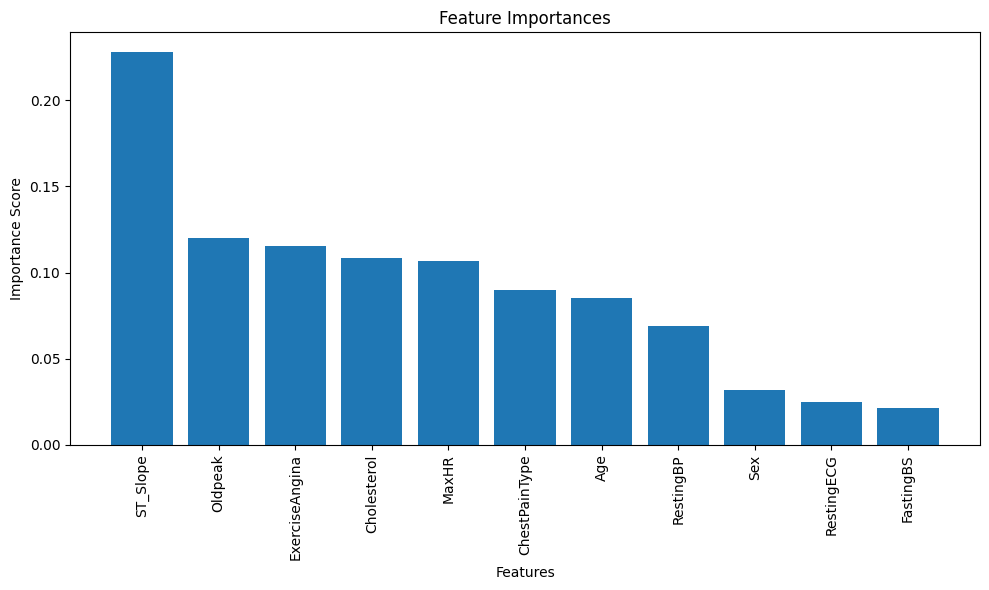

In [43]:
# Sort the features in descending order of importance

# Get feature importances and respective names
feature_importance = model.feature_importances_
feature_names = model.feature_names_in_

# Sort feature importances in descending order
sorted_idx = feature_importance.argsort()[::-1]

# Get names of top features
top_features = [feature_names[i] for i in sorted_idx]

# Plotting the most important features
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx])
plt.xticks(range(len(feature_importance)), top_features, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importances')
plt.tight_layout()

plt.show()